In [43]:
# импорты и настройки
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import sounddevice as sd
from scipy.fft import fft, fftfreq

# настройки графиков
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["axes.grid"] = True


In [54]:
# исходные данные

# обой C5
A = [1, 0.5, 0.2, 0.1]
f0 = 523
h = [1, 2, 3, 4]
phi = 0

# параметры дискретизации
fs = 10460  # частота дискретизации
duration = 128 / fs  # длительность сигнала
t = np.arange(0, duration, 1 / fs)  # временная ось


In [55]:
# генерация сигнала


def generate_signal(A, h, f0, phi, t):
    signals = [
        Ai * np.sin(2 * np.pi * hi * f0 * t + phi) for Ai, hi in zip(A, h, strict=True)
    ]
    return np.sum(signals, axis=0)


x = generate_signal(A, h, f0, phi, t)

N = len(x)
X = fft(x)
freqs = fftfreq(N, 1 / fs)
idx = np.arange(N // 2)


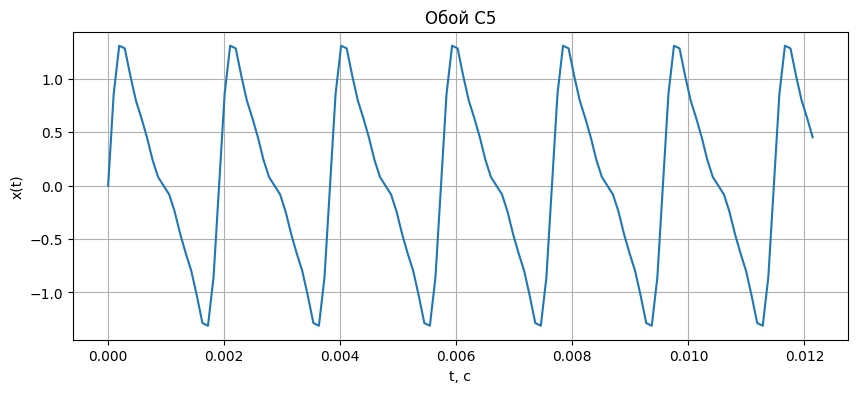

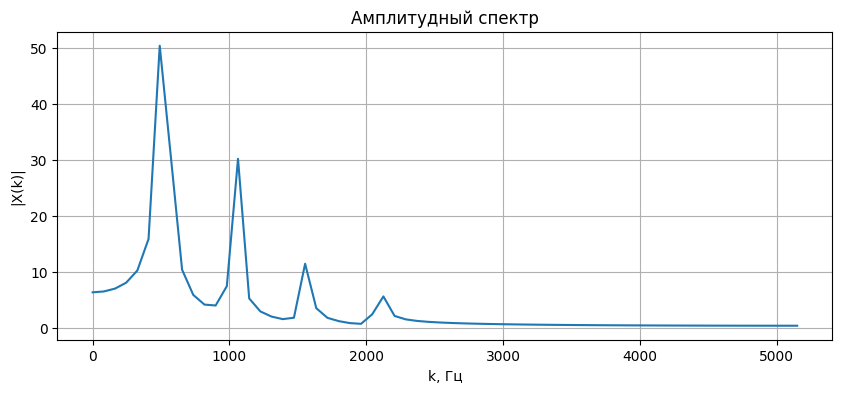

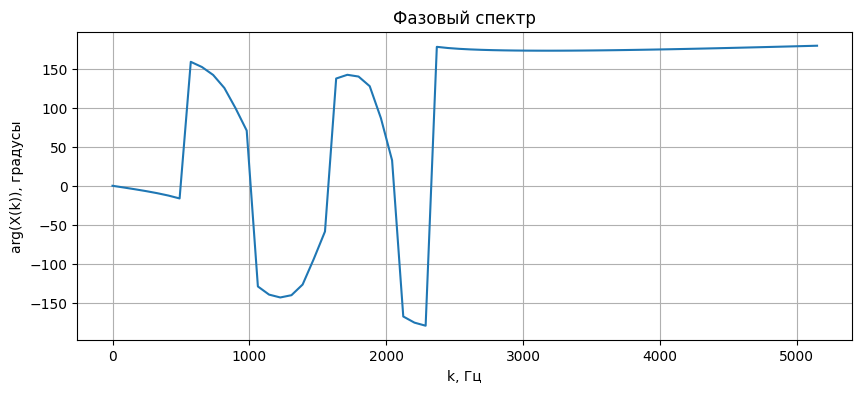

In [56]:
plt.figure()
plt.plot(t, x)
plt.title("Обой C5")
plt.xlabel("t, с")
plt.ylabel("x(t)")
plt.show()

plt.plot(freqs[idx], np.abs(X[idx]))
plt.title("Амплитудный спектр")
plt.xlabel("k, Гц")
plt.ylabel("|X(k)|")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(freqs[idx], np.angle(X[idx], deg=True))
plt.title("Фазовый спектр")
plt.xlabel("k, Гц")
plt.ylabel("arg(X(k)), градусы")
plt.show()